## Decision Tree Agent

This notebook mirrors `src/03_decision_tree.py` so you can:

- **Train** a shallow decision tree on all `*.jsonl` files in a data folder (state → action).
- **Inspect** hold-out accuracy and (optionally) plot the tree.
- **Compare** the model to a few recorded frames before running the live Godot loop.

**Recording your own sessions:** run `src/02_record_gameplay.py` (e.g. `python src/02_record_gameplay.py` from the repo root) to record gameplay as `.jsonl` files. You need those recordings to train this kind of imitation-learning agent; save or copy them under `DATA_DIR` (top-level `*.jsonl` only).

Observation layout is the same as elsewhere: see `00_data_exploration.ipynb`. Training only uses top-level `*.jsonl` in the chosen directory (not subfolders); point `DATA_DIR` at a folder that contains your recordings.

### Setup and training helpers

The functions below match `03_decision_tree.py`; tweak `max_depth`, `test_size`, or `random_state` when you call `train_decision_tree_classifier`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

from utils import load_observations_by_session, setup_environment

DEFAULT_DATA_DIR = Path("../data")


def load_training_xy(data_dir: Path | str = DEFAULT_DATA_DIR):
    data_dir = Path(data_dir)
    all_data = {}
    for i, file in enumerate(sorted(data_dir.glob("*.jsonl"))):
        observations_by_session = load_observations_by_session(file)
        for session_id, all_steps in observations_by_session.items():
            all_data[f"{i}_{session_id}"] = all_steps

    X, y = [], []
    for _session_id, all_steps in all_data.items():
        for step in all_steps:
            X.append(step["state"])
            y.append(step["action"])
    return X, y


def train_decision_tree_classifier(
    data_dir: Path | str = DEFAULT_DATA_DIR,
    *,
    test_size: float = 0.2,
    random_state: int = 42,
    max_depth: int = 3,
):
    X, y = load_training_xy(data_dir)
    if not X:
        raise FileNotFoundError(
            f"No training rows found under {data_dir} (*.jsonl)."
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    model = tree.DecisionTreeClassifier(
        max_depth=max_depth, class_weight="balanced"
    )
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Decision tree accuracy (hold-out): {accuracy:.2f}")
    return model


def agent_brain(observation, step_count, model):
    # You need to press jump on the first frame to start walking.
    if step_count == 0:
        return [1]

    pred = model.predict([observation])[0]
    return [int(pred)]

### Train the classifier

If you have no `.jsonl` files yet, record gameplay with `src/02_record_gameplay.py` first.

If you get “no training rows”, add `.jsonl` files directly under `DATA_DIR`, or change `DATA_DIR` to a folder that already contains them (the stock script’s `glob` is not recursive).

In [2]:
DATA_DIR = Path("../data")

model = train_decision_tree_classifier(
    data_dir=DATA_DIR,
    max_depth=3,
    test_size=0.2,
    random_state=42,
)

Decision tree accuracy (hold-out): 0.82


### Prototype on recorded data

Sanity-check the trained model on a single frame: human label vs prediction (for `step_count > 0` the tree is used; step `0` is always jump in `agent_brain`).

In [3]:
RECORDING = Path("../data/cheatsheet/session_1/demo.jsonl")
FRAME_INDEX = 0

by_session = load_observations_by_session(RECORDING)
session_id = next(iter(by_session))
frame = by_session[session_id][FRAME_INDEX]
state = frame["state"]
human_action = int(frame["action"])

print("human action:", human_action)
print("model (raw predict):", int(model.predict([state])[0]))
print("agent_brain step 0:", agent_brain(state, 0, model))
print("agent_brain step 5:", agent_brain(state, 5, model))

human action: 1
model (raw predict): 0
agent_brain step 0: [1]
agent_brain step 5: [0]


### Plot the decision tree (optional)

Large observation vectors produce wide figures; shrink `figsize` or `max_depth` if this is hard to read.

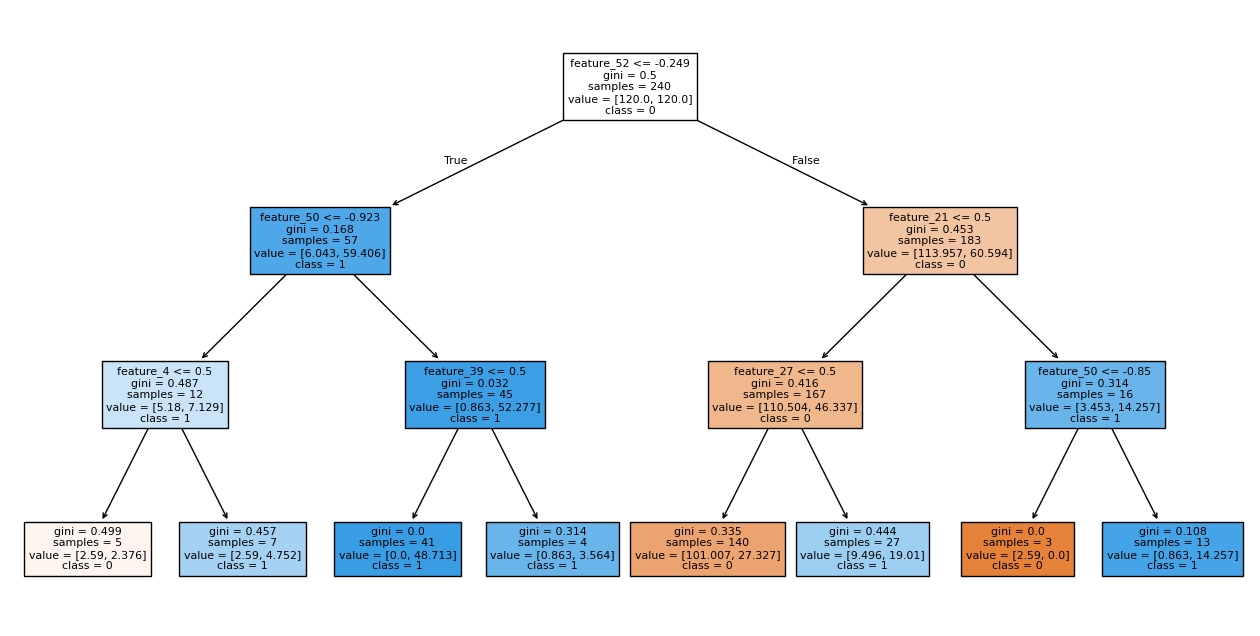

In [4]:
feature_names = [f"feature_{i}" for i in range(model.n_features_in_)]
class_names = [str(c) for c in model.classes_]

plt.figure(figsize=(16, 8))
plot_tree(model, filled=True, feature_names=feature_names, class_names=class_names)
plt.show()

### Run the live environment

Requires Godot / env paths from `src/.config` (same as `python src/03_decision_tree.py`). **Interrupt the kernel** to stop early.

In [5]:
env = setup_environment()
obs = env.reset()
nb_agents = len(obs["obs"])

step_count = 0
while True:
    actions = [
        agent_brain(obs["obs"][i], step_count, model) for i in range(nb_agents)
    ]
    actions = np.array(actions, dtype=np.int64)
    obs, reward, done, info = env.step(actions)
    if any(done):
        break
    step_count += 1

env.close()

Loaded environment variables from d:\projects\PLaiGROUND\src\.config
D:\gamedev\dragon-jump-remaster\builds\windows\DragonJump.exe
waiting for remote GODOT connection on port 11008
connection established
action space [{'jump': {'size': 1, 'action_type': 'discrete'}}]
observation space [{'obs': {'size': [57], 'space': 'box'}}]
close message sent
